# Document Parsing using Unlimited-OCR and OpenVINO

**[Unlimited-OCR](https://huggingface.co/baidu/Unlimited-OCR)** is a vision-language model (VLM) from Baidu for efficient, high-resolution document understanding and optical character recognition (OCR). It pairs a deep dual vision encoder (SAM ViT-B + CLIP-L) and a linear projector with a compact DeepSeek-V2 **Mixture-of-Experts** decoder (12 layers, 64 routed + 2 shared experts, top-6). Every decoder layer uses **sliding-window attention** (window = 128) during generation while keeping all prefill (image/prompt) tokens visible, and dynamic image tiling lets it read very large documents.

More details can be found in the original [model card](https://huggingface.co/baidu/Unlimited-OCR).

In this tutorial we consider how to convert and run Unlimited-OCR using [OpenVINO](https://github.com/openvinotoolkit/openvino) and optimize it using [NNCF](https://github.com/openvinotoolkit/nncf).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Download the original model](#Download-the-original-model)
- [Convert model to OpenVINO Intermediate Representation](#Convert-model-to-OpenVINO-Intermediate-Representation)
- [Prepare inference pipeline](#Prepare-inference-pipeline)
- [Run model inference](#Run-model-inference)
- [Interactive demo](#Interactive-demo)

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/unlimited-ocr/unlimited-ocr.ipynb" />

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
import requests
from pathlib import Path

utility_files = ["cmd_helper.py", "notebook_utils.py", "pip_helper.py"]
base_utility_url = "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/"

for utility in utility_files:
    if not Path(utility).exists():
        r = requests.get(base_utility_url + utility)
        with open(utility, "w", encoding="utf-8") as f:
            f.write(r.text)

In [2]:
from pip_helper import pip_install

pip_install("-Uq", "--pre", "openvino", "--extra-index-url", "https://storage.openvinotoolkit.org/simple/wheels/nightly")
pip_install(
    "-q",
    "nncf>=2.15",
    "torch==2.8.0",
    "transformers==4.46.3",
    "tokenizers==0.20.3",
    "torchvision==0.23.0",
    "einops",
    "addict",
    "easydict",
    "huggingface_hub",
    "accelerate>=0.26.0",
    "PyMuPDF",
    "gradio>=4.19,<6",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)

## Download the original model
[back to top ⬆️](#Table-of-contents:)

The model is downloaded from the Hugging Face Hub into a local folder named `Unlimited_OCR` (with an underscore so it can be imported as a Python package by the helper).

In [3]:
from huggingface_hub import snapshot_download

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("unlimited-ocr.ipynb")

model_id = "baidu/Unlimited-OCR"
local_dir = "Unlimited_OCR"

print(f"Downloading {model_id} to {local_dir}...")
snapshot_download(repo_id=model_id, local_dir=local_dir, local_dir_use_symlinks=False)
print(f"Model downloaded successfully to {local_dir}")

D:\optimum-intel\py_env\Lib\site-packages\huggingface_hub\file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

assets/long-horizon-ocr.gif:   0%|          | 0.00/82.2M [00:00<?, ?B/s]

assets/Unlimited-OCR.png:   0%|          | 0.00/106k [00:00<?, ?B/s]

Unlimited-OCR.pdf:   0%|          | 0.00/460k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

wheel/sglang-0.0.0.dev11416+g92e8bb79e-p(…):   0%|          | 0.00/12.5M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model downloaded successfully to Unlimited_OCR


## Convert model to OpenVINO Intermediate Representation
[back to top ⬆️](#Table-of-contents:)

Unlimited-OCR is a PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). The [OpenVINO model conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html) should be used for these purposes. `ov.convert_model` accepts the original PyTorch model instance and example input for tracing and returns an `ov.Model`. The converted model can be saved with `ov.save_model` or loaded directly with `core.compile_model`.

The script `ov_unlimited_ocr_helper.py` contains the helper function `convert_unlimited_ocr` for model conversion. It splits the model into the following OpenVINO sub-models:

- **text embeddings** — token embedding lookup;
- **vision embeddings** — the SAM + CLIP encoders and the linear projector, exported at two fixed square resolutions (the 1024 global view and the 640 crop tiles), each with a dynamic batch dimension so the variable number of crop tiles is handled at runtime. Two IRs are used because the SAM/CLIP positional-embedding interpolation is resolution dependent and cannot be traced as a single dynamic-resolution graph;
- **language model** — the stateful DeepSeek-V2 MoE decoder. Its MoE routing is rewritten as a static loop over all experts, and the sliding-window attention (window = 128) is reproduced with an explicit additive mask built at inference time so every query attends to all prefill tokens plus the last 128 generated tokens.

Please check the helper's content for conversion details.

Weight compression with [NNCF](https://github.com/openvinotoolkit/nncf) can be optionally applied to reduce the model footprint. When the checkbox below is enabled, the language model is compressed to INT4 (`INT4_SYM`, group size 64) and the vision encoder to INT8 (`INT8_ASYM`).

In [4]:
import ipywidgets as widgets

to_compress = widgets.Checkbox(value=True, description="Compression")
to_compress

Checkbox(value=True, description='Compression')

In [5]:
import nncf
from ov_unlimited_ocr_helper import convert_unlimited_ocr

quantization_config = None
if to_compress.value:
    quantization_config = {
        "vision": {"mode": nncf.CompressWeightsMode.INT8_ASYM},
        "llm": {"mode": nncf.CompressWeightsMode.INT4_SYM, "group_size": 64, "ratio": 1.0},
    }

model_path = Path(local_dir) / ("INT4" if to_compress.value else "FP16")
convert_unlimited_ocr(local_dir, model_path=model_path, quantization_config=quantization_config)

⌛ Unlimited_OCR conversion started. Be patient, it may take some time.
⌛ Load Original model


Some weights of UnlimitedOCRForCausalLM were not initialized from the model checkpoint at Unlimited_OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Original model successfully loaded
⌛ Convert Input embedding model


D:\optimum-intel\py_env\Lib\site-packages\transformers\modeling_utils.py:5006: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


✅ Input embedding model successfully converted
⌛ Convert Image embedding model (1024x1024)


...

D:\optimum-intel\py_env\Lib\site-packages\transformers\cache_utils.py:443: TracerWarning: Using len to get tensor shape might cause the trace to be incorrect. Recommended usage would be tensor.shape[0]. Passing a tensor of different shape might lead to errors or silently give incorrect results.
  elif len(self.key_cache[layer_idx]) == 0:  # fills previously skipped layers; checking for tensor causes errors


✅ Language model successfully converted
⌛ Weights compression with int4_sym mode started
INFO:nncf:Statistics of the bitwidth distribution:
+---------------------------+-----------------------------+----------------------------------------+
| Weight compression mode   | % all parameters (layers)   | % ratio-defining parameters (layers)   |
+===========================+=============================+========================================+
| int8_asym, per-channel    | 6% (1 / 2208)               | 0% (0 / 2207)                          |
+---------------------------+-----------------------------+----------------------------------------+
| int4_sym, group size 64   | 94% (2207 / 2208)           | 100% (2207 / 2207)                     |
+---------------------------+-----------------------------+----------------------------------------+


Output()

✅ Weights compression finished
✅ Unlimited_OCR model conversion finished. You can find results in Unlimited_OCR\INT4


WindowsPath('Unlimited_OCR/INT4')

## Prepare inference pipeline
[back to top ⬆️](#Table-of-contents:)

The `OVUnlimitedOCRForCausalLM` class defined in `ov_unlimited_ocr_helper.py` represents the model inference class. It accepts a path to the converted model directory and a target device for inference. Like the original pipeline, it exposes an `infer` method that takes a tokenizer, a prompt and an image file.

In [6]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [7]:
from transformers import AutoTokenizer
from ov_unlimited_ocr_helper import OVUnlimitedOCRForCausalLM

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = OVUnlimitedOCRForCausalLM(model_path, device=device.value)

## Run model inference
[back to top ⬆️](#Table-of-contents:)

Let's check the model prediction for document parsing.

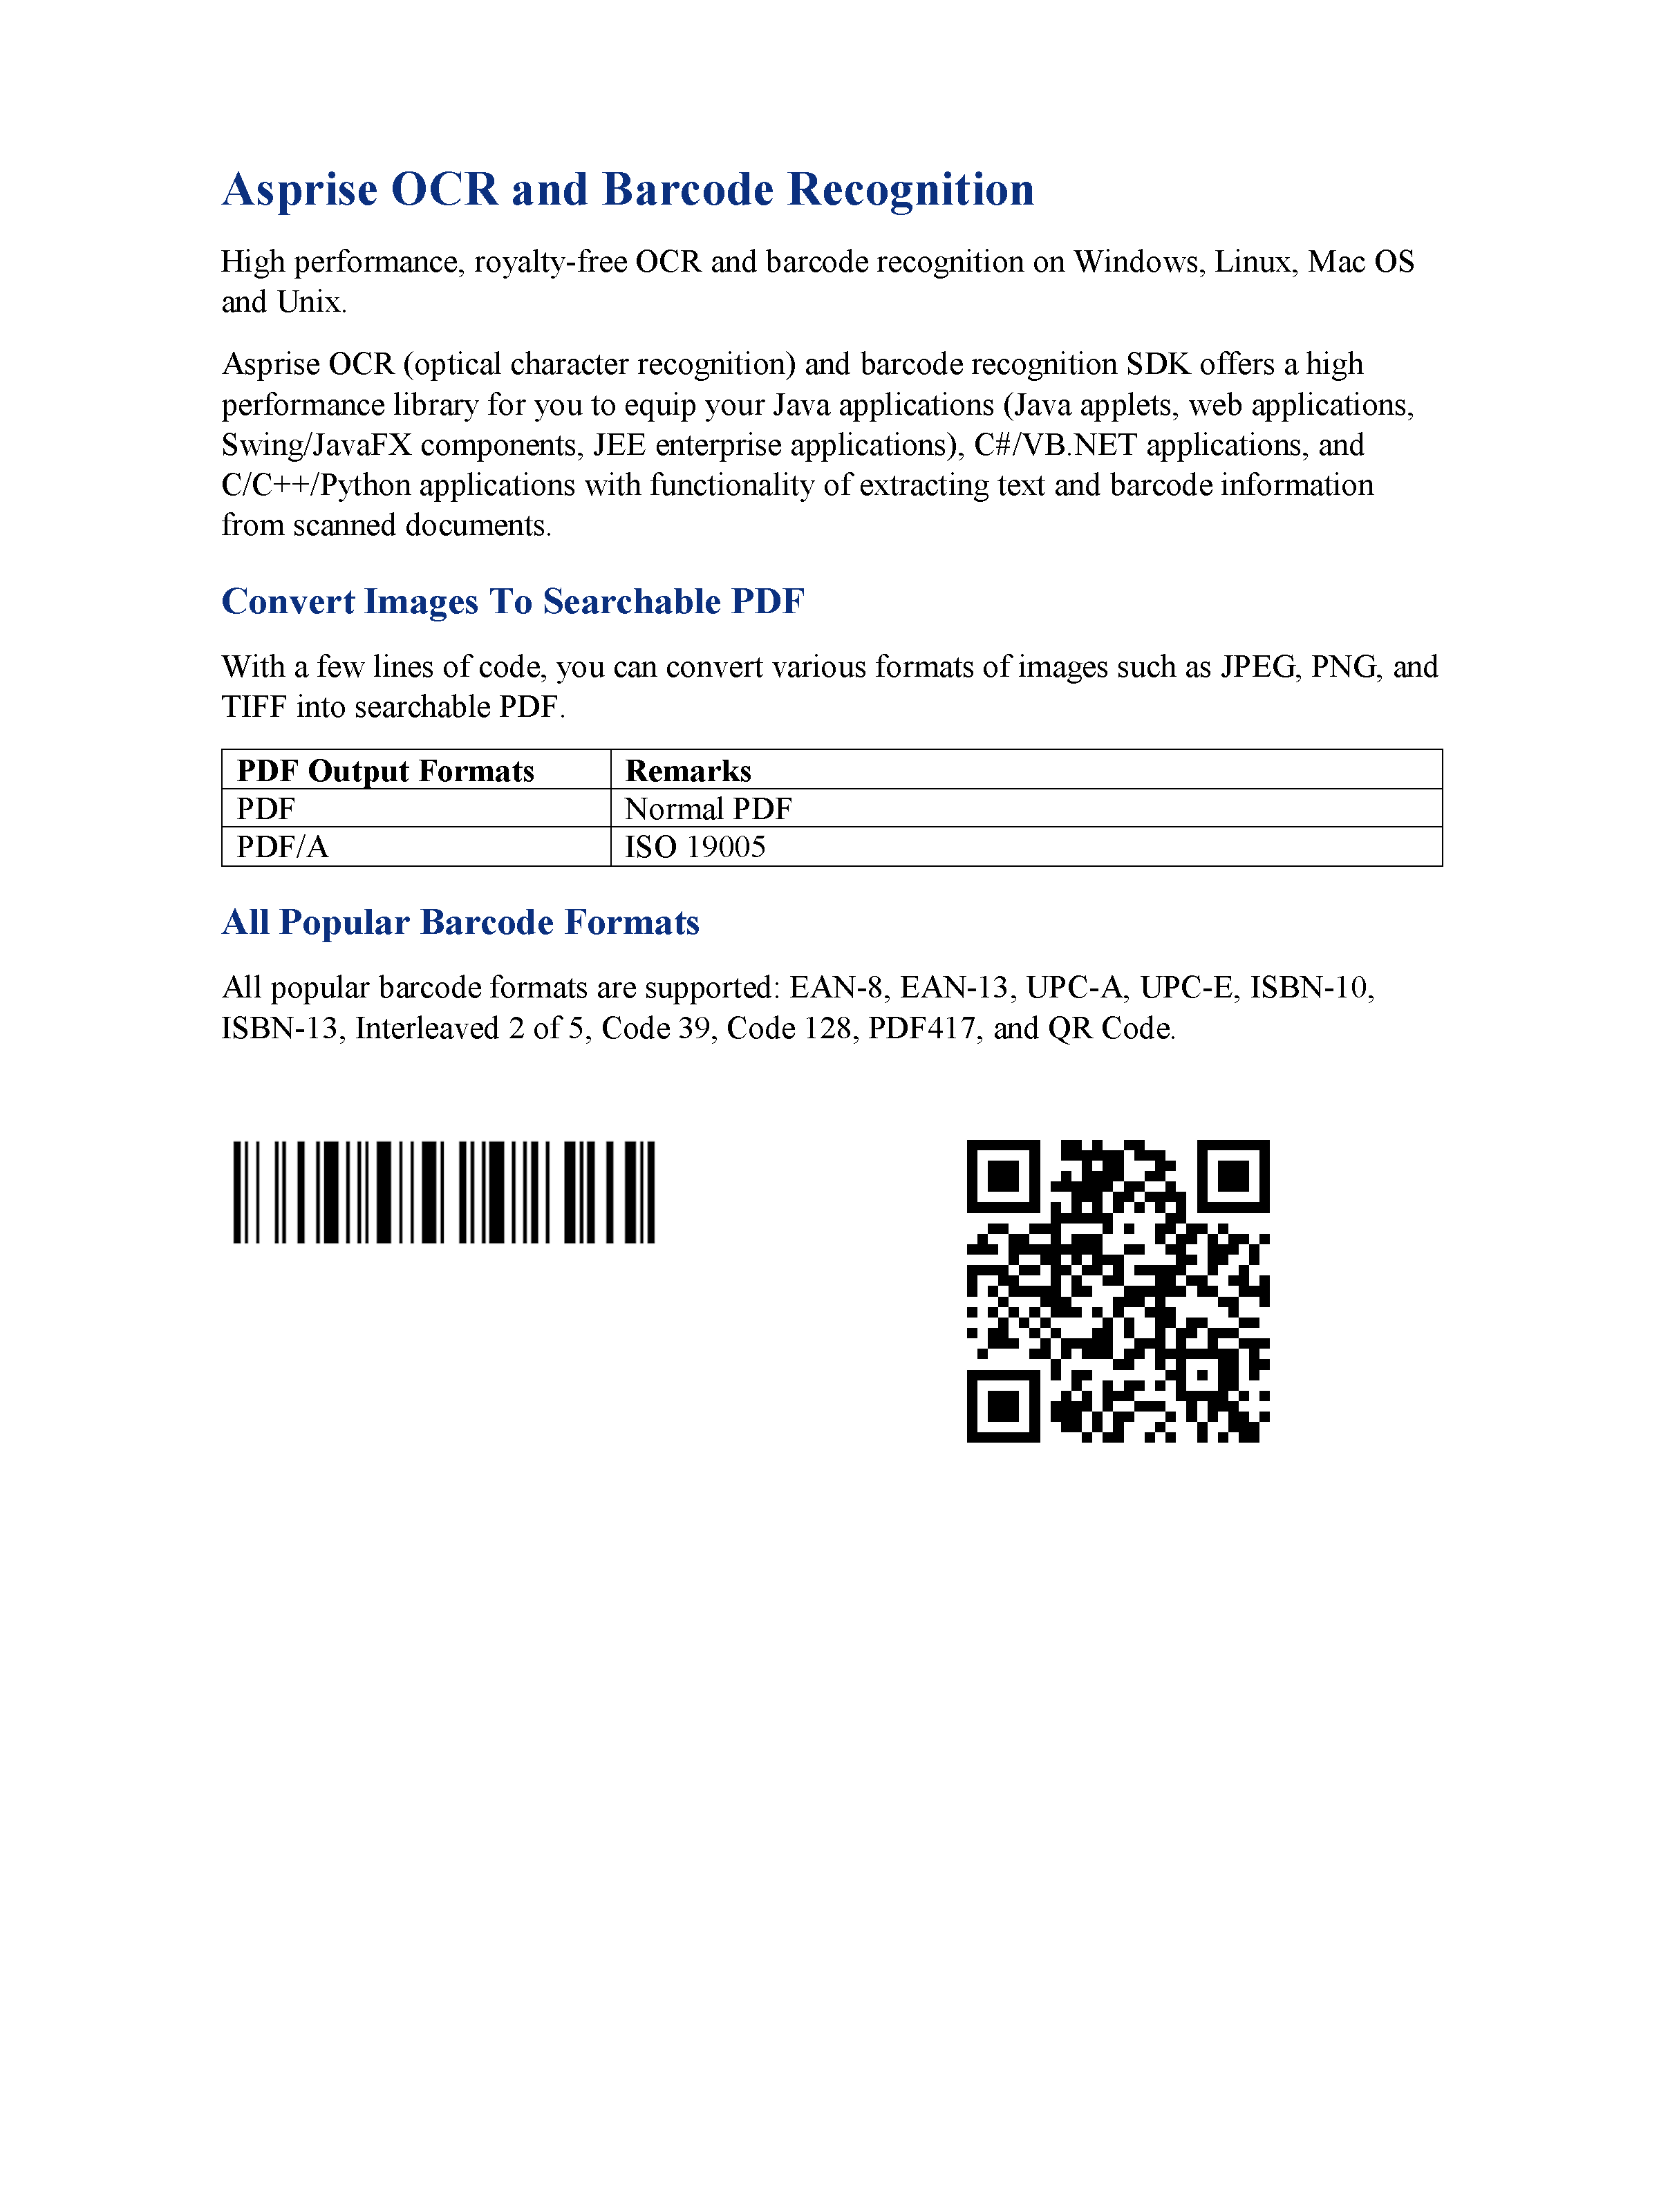

In [8]:
from PIL import Image

url = "https://huggingface.co/spaces/khang119966/DeepSeek-OCR-DEMO/resolve/main/doc_markdown.png"
file_name = "doc_markdown.png"
if not Path(file_name).exists():
    Image.open(requests.get(url, stream=True).raw).save(file_name)

Image.open(file_name)

In [9]:
prompt = "<image>document parsing."
output_path = "."

res = model.infer(
    tokenizer,
    prompt=prompt,
    image_file=file_name,
    output_path=output_path,
    base_size=1024,
    image_size=640,
    crop_mode=True,
    no_repeat_ngram_size=35,
    ngram_window=128,
    save_results=True,
    test_compress=True,
)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|det|>title [129, 75, 628, 99]<|/det|>Asprise OCR and Barcode Recognition
<|det|>text [128, 110, 856, 145]<|/det|>High performance, royalty-free OCR and barcode recognition on Windows, Linux, Mac OS and Unix.
<|det|>text [128, 156, 854, 244]<|/det|>Asprise OCR (optical character recognition) and barcode recognition SDK offers a high performance library for you to equip your Java applications (Java applets, web applications, Swing/JavaFX components, JEE enterprise applications), C#/VB.NET applications, and C/C++/Python applications with functionality of extracting text and barcode information from scanned documents.
<|det|>title [129, 262, 486, 280]<|/det|>Convert Images To Searchable PDF
<|det|>text [128, 291, 871, 326]<|/det|>With a few lines of code, you can convert various formats of images such as JPEG, PNG, and TIFF into searchable PDF.
<|det|>table [132, 336, 872, 393]<|/det|><table><tr><td>PDF Output Formats</td><td>Remarks</td></tr><tr><td>PDF</td><td>Normal PDF</td></tr><tr><

other: 100%|███████████████████████████████████████████████████████████████████| 8/8 [00:00<?, ?it/s]


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(model, tokenizer)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/